In [85]:
"""
Задание 1. Задача классификации
Для набора данных "Ирисы Фишера":

1)Загрузить данные, разбить на тренировочную и обучающую выборки.
2)Обучить на тренировочной, оценить точность модели на тестовой выборке для GaussianNB(), MultinomialNB(), KNeighborsClassifier().
  Прокомментировать полученные результаты. 
  В каждом случае построить матрицы ConfusionMatrix, отчеты о классификации (4 балла).
3)Показать, что точность модели kNN зависит от выбранного числа соседей (2 балла).
    При желании можно строить и границы решений. Для этого будет полезна следующая функция. 
    Но, обратите внимание, в ней используются только 2 признака (из 4 в рассматриваемом наборе).
"""

'\nЗадание 1. Задача классификации\nДля набора данных "Ирисы Фишера":\n\n1)Загрузить данные, разбить на тренировочную и обучающую выборки.\n2)Обучить на тренировочной, оценить точность модели на тестовой выборке для GaussianNB(), MultinomialNB(), KNeighborsClassifier().\n  Прокомментировать полученные результаты. \n  В каждом случае построить матрицы ConfusionMatrix, отчеты о классификации (4 балла).\n3)Показать, что точность модели kNN зависит от выбранного числа соседей (2 балла).\n    При желании можно строить и границы решений. Для этого будет полезна следующая функция. \n    Но, обратите внимание, в ней используются только 2 признака (из 4 в рассматриваемом наборе).\n'

In [86]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions

In [87]:
# использует только 2 признака для обучения!
# X, y - набор данных для отображения, X_train, y_train - данные для обучения
def decision_boundary_plot(X, y, X_train, y_train, clf, feature_indexes, title=None):
    feature1_name, feature2_name = X.columns[feature_indexes]
    X_feature_columns = X.values[:, feature_indexes]
    X_train_feature_columns = X_train[:, feature_indexes]
    clf.fit(X_train_feature_columns, y_train)

    plot_decision_regions(X=X_feature_columns, y=y.values, clf=clf)
    plt.xlabel(feature1_name)
    plt.ylabel(feature2_name)
    plt.title(title)

In [88]:
#1
X, y = load_iris(return_X_y=True, as_frame=True)
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=5)

Точность у обученной модели:0.9732142857142857
Точность у обученной модели:0.9210526315789473
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.87      0.93      0.90        14
           2       0.91      0.83      0.87        12

    accuracy                           0.92        38
   macro avg       0.93      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



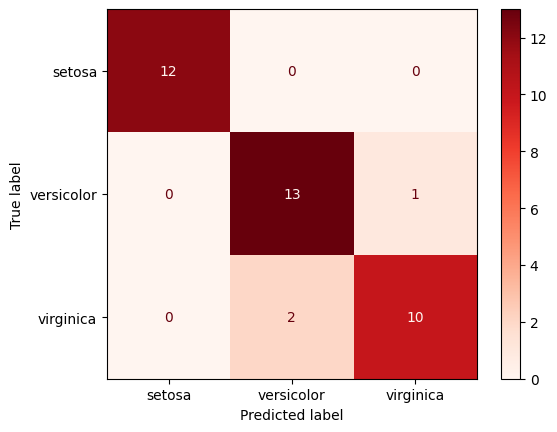

In [89]:
#2 - на классификаторе GaussianNB
clf = GaussianNB()
clf.fit(X_train, y_train)
clf_pred = clf.predict(X_train)

#Точность высока из-за тог  о, что модель уже знает эти признаки и отлично справляется с ними
clf_accuracy = accuracy_score(y_train, clf_pred)
print(f"Точность у обученной модели:{clf_accuracy}")

#Точность чуть ниже из-за того, что модель первый раз видит эти признаки
clf_pred = clf.predict(X_test)
clf_accuracy = accuracy_score(y_test, clf_pred)
print(f"Точность у обученной модели:{clf_accuracy}")

#матрица ошибок - ConfusionMatrix
# 7. Строим матрицу ошибок
cm = confusion_matrix(y_test, clf_pred, labels=[0, 1, 2]
                      #labels=clf.classes_
                      )
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels= iris.target_names
                              #display_labels=clf.classes_
                              )
disp.plot(cmap=plt.cm.Reds)

#Отчет о классификации
print(classification_report(y_test, clf_pred))


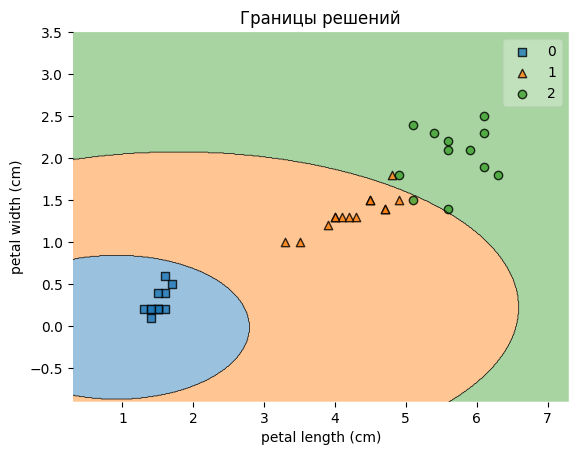

In [90]:
#Границы решений - petal/лепесток - sepals/чашелистик
feature_indexes = [2, 3]
title1 = 'Границы решений'
decision_boundary_plot(X_test, y_test, X_train.values, y_train.values, clf, feature_indexes, title1)

Точность у обученной модели:0.9553571428571429
Точность у обученной модели:0.868421052631579
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.64      0.78        14
           2       0.71      1.00      0.83        12

    accuracy                           0.87        38
   macro avg       0.90      0.88      0.87        38
weighted avg       0.91      0.87      0.87        38



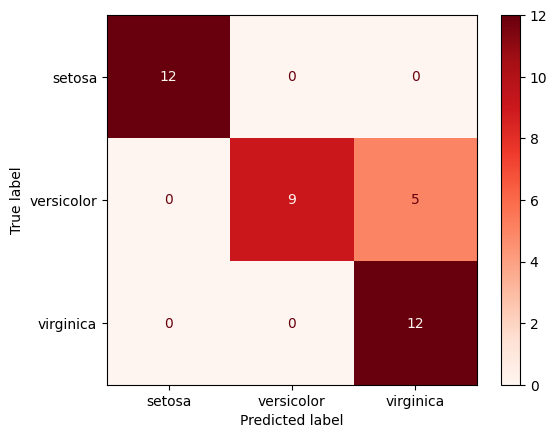

In [91]:
#2 - на классификаторе MultinomialNB
clf = MultinomialNB()
clf.fit(X_train, y_train)
clf_pred = clf.predict(X_train)

#Точность высока из-за тог  о, что модель уже знает эти признаки и отлично справляется с ними
clf_accuracy = accuracy_score(y_train, clf_pred)
print(f"Точность у обученной модели:{clf_accuracy}")

#Точность чуть ниже из-за того, что модель первый раз видит эти признаки
clf_pred = clf.predict(X_test)
clf_accuracy = accuracy_score(y_test, clf_pred)
print(f"Точность у обученной модели:{clf_accuracy}")

#матрица ошибок - ConfusionMatrix
# 7. Строим матрицу ошибок
cm = confusion_matrix(y_test, clf_pred, labels=[0, 1, 2]
                      #labels=clf.classes_
                      )
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels= iris.target_names
                              #display_labels=clf.classes_
                              )
disp.plot(cmap=plt.cm.Reds)

#Отчет о классификации
print(classification_report(y_test, clf_pred))

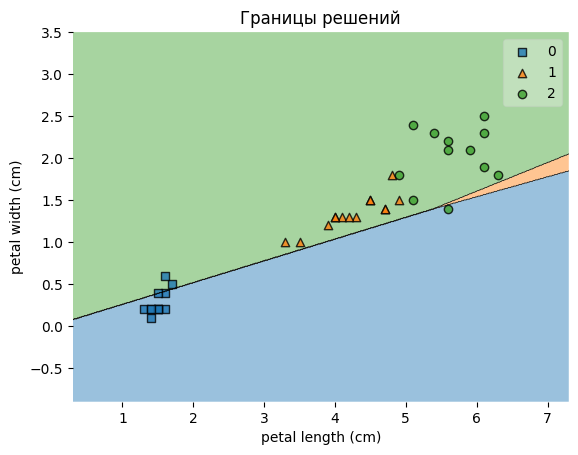

In [92]:
#Границы решений - petal/лепесток - sepals/чашелистик
feature_indexes = [2, 3]
title1 = 'Границы решений'
decision_boundary_plot(X_test, y_test, X_train.values, y_train.values, clf, feature_indexes, title1)

Точность у обученной модели:0.9732142857142857
Точность у обученной модели:0.9473684210526315
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.86      0.92        14
           2       0.86      1.00      0.92        12

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



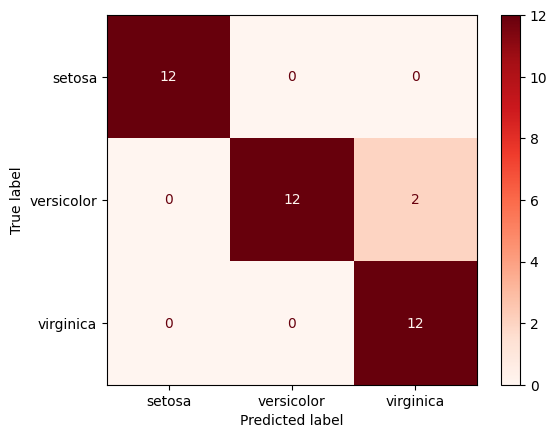

In [93]:
#3 - на классификаторе KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)
clf_pred = clf.predict(X_train)

#Точность высока из-за тог  о, что модель уже знает эти признаки и отлично справляется с ними
clf_accuracy = accuracy_score(y_train, clf_pred)
print(f"Точность у обученной модели:{clf_accuracy}")

#Точность чуть ниже из-за того, что модель первый раз видит эти признаки
clf_pred = clf.predict(X_test)
clf_accuracy = accuracy_score(y_test, clf_pred)
print(f"Точность у обученной модели:{clf_accuracy}")

#матрица ошибок - ConfusionMatrix
# 7. Строим матрицу ошибок
cm = confusion_matrix(y_test, clf_pred, labels=[0, 1, 2]
                      #labels=clf.classes_
                      )
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels= iris.target_names
                              #display_labels=clf.classes_
                              )
disp.plot(cmap=plt.cm.Reds)

#Отчет о классификации
print(classification_report(y_test, clf_pred))

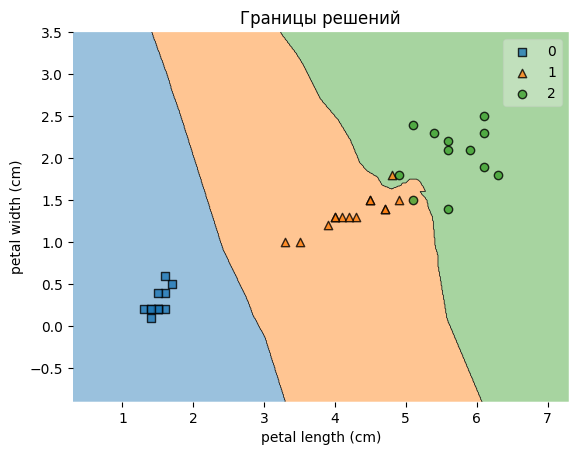

In [94]:
#Границы решений - petal/лепесток - sepals/чашелистик
feature_indexes = [2, 3]
title1 = 'Границы решений'
decision_boundary_plot(X_test, y_test, X_train.values, y_train.values, clf, feature_indexes, title1)

In [95]:
#3 - зависимость от числа соседей KNN
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)
clf_pred = clf.predict(X_train)
clf_accuracy = accuracy_score(y_train, clf_pred)
print(clf_accuracy)

clf = KNeighborsClassifier(n_neighbors=9)
clf.fit(X_train, y_train)
clf_pred = clf.predict(X_train)
clf_accuracy = accuracy_score(y_train, clf_pred)
print(clf_accuracy)

clf = KNeighborsClassifier(n_neighbors=27)
clf.fit(X_train, y_train)
clf_pred = clf.predict(X_train)
clf_accuracy = accuracy_score(y_train, clf_pred)
print(clf_accuracy)

0.9732142857142857
0.9821428571428571
0.9375
